In [136]:
import pandas as pd
import numpy as np

df = pd.read_csv("dataset/cleaned_5250.csv")

# Verificando se o DF foi importado com sucesso:
df.head(10)


,name,distance,stellar_magnitude,planet_type,discovery_year,mass_multiplier,mass_wrt,radius_multiplier,radius_wrt,orbital_radius,orbital_period,eccentricity,detection_method
0,11 Comae Berenices b,304.0,4.72307,Gas Giant,2007,19.40000,Jupiter,1.080,Jupiter,1.290000,0.892539,0.23,Radial Velocity
1,11 Ursae Minoris b,409.0,5.01300,Gas Giant,2009,14.74000,Jupiter,1.090,Jupiter,1.530000,1.400000,0.08,Radial Velocity
2,14 Andromedae b,246.0,5.23133,Gas Giant,2008,4.80000,Jupiter,1.150,Jupiter,0.830000,0.508693,0.00,Radial Velocity
3,14 Herculis b,58.0,6.61935,Gas Giant,2002,8.13881,Jupiter,1.120,Jupiter,2.773069,4.800000,0.37,Radial Velocity
4,16 Cygni B b,69.0,6.21500,Gas Giant,1996,1.78000,Jupiter,1.200,Jupiter,1.660000,2.200000,0.68,Radial Velocity
5,17 Scorpii b,408.0,5.22606,Gas Giant,2020,4.32000,Jupiter,1.150,Jupiter,1.450000,1.600000,0.06,Radial Velocity
6,18 Delphini b,249.0,5.51048,Gas Giant,2008,10.30000,Jupiter,1.110,Jupiter,2.600000,2.700000,0.08,Radial Velocity
7,1RXS J160929.1-210524 b,454.0,12.61800,Gas Giant,2008,8.00000,Jupiter,1.664,Jupiter,330.000000,6505.900000,0.00,Direct Imaging
8,24 Bootis b,313.0,5.59000,Gas Giant,2018,0.91000,Jupiter,1.240,Jupiter,0.190000,0.083231,0.04,Radial Velocity
9,24 Sextantis b,235.0,6.45350,Gas Giant,2010,1.99000,Jupiter,1.190,Jupiter,1.333000,1.239699,0.09,Radial Velocity


Antes de começar o tratamento dos dados, note que existem planetas em que o multiplicador de massa e de raio é feito em relação à Jupiter, enquanto outros, são feitos em relação à Terra. Precisaremos normalizar esses dois tipos diferentes de dados. Para isso, irei utilizar como base a massa e o raio de Jupiter (que possui um número maior de recorrências) e transformarei os dados que possuem essa dependência

In [128]:
# Fatores de conversão (aproximados)
# Massa de Júpiter é ~317.8 vezes a massa da Terra
# Raio de Júpiter é ~11.2 vezes o raio da Terra
massa_jupiter_em_terras = 317.8
raio_jupiter_em_terras = 11.2

# --- Conversão da Massa ---
mascara_massa_terra = df['mass_wrt'] == 'Earth'

df.loc[mascara_massa_terra, 'mass_multiplier'] = df.loc[mascara_massa_terra, 'mass_multiplier'] / massa_jupiter_em_terras

# --- Conversão do Raio ---
mascara_raio_terra = df['radius_wrt'] == 'Earth'

df.loc[mascara_raio_terra, 'radius_multiplier'] = df.loc[mascara_raio_terra, 'radius_multiplier'] / raio_jupiter_em_terras

# Excluindo as colunas 'radius_wrt' e 'mass_wrt', que agora são inúteis:

df = df.drop(['mass_wrt','radius_wrt'],axis=1)


Agora, precisamos extrair algumas informações que sejam relevantes que saíbamos utilizar antes de começar o treinamento, como se existem valores ausentes no datagrame. Para isso, podemos usar o método isnull do pandas:

In [129]:
df.isnull().any()

name                 False
distance              True
stellar_magnitude     True
planet_type          False
discovery_year       False
mass_multiplier       True
radius_multiplier     True
orbital_radius        True
orbital_period       False
eccentricity         False
detection_method     False
dtype: bool

Como foi possível perceber acima, existem valores nulos no dataframe. Esses valores podem contribuir negativamente para a qualidade do nosso estimador.

Precisamos tratar de alguma forma o nosso conjunto de dados para substituir esses valores. Existem algumas técnicas para contornar essa situação, como inserir na posição dos valores faltantes a média ou a mediana dos valores de cada uma das colunas. Também é possível usar um modelo de regressão para preencher esses valores em função das outras colunas.

Sabemos que a média é sensível a outliers, para verificar se esse é o caso do nosso dataframe, vamos plotar o boxplot do dataframe:

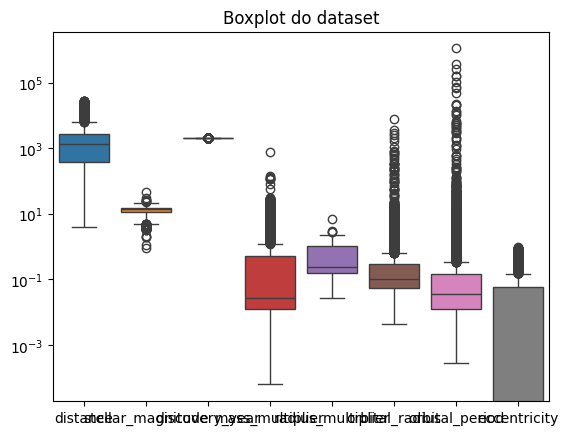

In [130]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=df)
plt.title('Boxplot do dataset') 
plt.yscale("log")
plt.show()

Colunas que indicam a distância do planeta à Terra ou o Ano de Descoberta são pouco relevantes para estimar o tipo do planeta, e por isso, podemos excluí-las.

Também usarei OneHotEncoding para tratar dados nominais como numéricos e trocarei os dados 'NaN' por '0'

Antes de aplicar o OneHotEncoding, removerei os planetas de tipo Desconhecido, uma vez que esse tipo de planeta não agregou nenhuma informação significativa para a análise dos dados e ainda acrescentou ruídos para a predição

In [131]:
df = df.drop(columns=['distance','name', 'discovery_year', 'detection_method']) # Removendo as colunas desnecessárias

df = df[df['planet_type'] != 'Unknown'] # Removendo os planetas de tipo "Unknown" do dataframe

df = pd.get_dummies(df) # Aplicando OneHotEncoding

columns_with_null = df.columns[df.isnull().any()].tolist() # Salvando o nome das colunas que possuem elementos NaNs

df = df.fillna(0) # Trocando os NaNs por 0

df


,stellar_magnitude,mass_multiplier,radius_multiplier,orbital_radius,orbital_period,eccentricity,planet_type_Gas Giant,planet_type_Neptune-like,planet_type_Super Earth,planet_type_Terrestrial
0,4.72307,19.400000,1.080000,1.290000,0.892539,0.23,True,False,False,False
1,5.01300,14.740000,1.090000,1.530000,1.400000,0.08,True,False,False,False
2,5.23133,4.800000,1.150000,0.830000,0.508693,0.00,True,False,False,False
3,6.61935,8.138810,1.120000,2.773069,4.800000,0.37,True,False,False,False
4,6.21500,1.780000,1.200000,1.660000,2.200000,0.68,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...
5245,10.52100,0.709000,1.373000,0.044210,0.007940,0.04,True,False,False,False
5246,10.88500,6.300000,1.140000,115.000000,1176.500000,0.00,True,False,False,False
5247,12.07400,0.002203,0.081518,0.016340,0.005476,0.06,False,False,False,True
5248,12.07400,0.003587,0.093750,0.021560,0.008487,0.00,False,False,True,False


Como foi possível perceber, existe um número considerável de outliers em quase todas as colunas do conjunto de dados, o que inviabiliza de preenchermos esses dados simplesmente com a média da coluna, que é uma métrica altamente sensível à outliers.

No entanto, podemos ajustar um modelo de regressão para cada uma das colunas com dados faltantes em função dos outros atributos e preencher esses os valores faltantes com os valores gerados a partir desse modelo.

Farei uma função que recebe como entrada a coluna desejada e o próprio dataframe e calcula um modelo de Random Regression a partir dos outros atributos. O valor de retorno será o Dataframe com o valor da coluna corrigida.

In [132]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
from math import sqrt

def fill_columns(df: pd.DataFrame, column: str):
    
    # Separando o conjunto de dados entre a parcela de treino e teste:
    y = df[column]
    name_column = y.name

    # Selecionando colunas com dados numéricos:
    X = df.select_dtypes(include='number').drop(name_column, axis=1)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    model = RandomForestRegressor(n_estimators=100, random_state=42)

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    RMSE = sqrt(mean_squared_error(y_true=y_test, y_pred=y_pred))

    r2 = r2_score(y_true=y_test, y_pred=y_pred)

    print(f'Coluna: {name_column} | Valor do RMSE: {RMSE} | Valor de R2: {r2}')

    y_pred_all = model.predict(X)

    # Create a copy to avoid SettingWithCopyWarning
    y_filled = y.copy()

    # Get indices where y is 0
    zero_indices = y[y == 0].index

    # Replace 0 values with predictions
    y_filled.loc[zero_indices] = y_pred_all[zero_indices]

    return y_filled


Com a função criada, vamos aplica-lá nas colunas com dados nulos:

In [133]:

df_reg = df.copy(deep=True)
for column in columns_with_null:
    new_column = fill_columns(df_reg,column)

    df_reg[column] = pd.Series(new_column)



Coluna: stellar_magnitude | Valor do RMSE: 2.5958121337025 | Valor de R2: 0.5524125425411399
Coluna: mass_multiplier | Valor do RMSE: 3.9651733609584916 | Valor de R2: 0.16553745126679342
Coluna: radius_multiplier | Valor do RMSE: 0.1402722563497557 | Valor de R2: 0.9129960793621238
Coluna: orbital_radius | Valor do RMSE: 137.20943223719377 | Valor de R2: 0.5990453789662702


Conforme foi possível perceber, conseguimos fazer o tratamento dos dados faltantes no dataset e agora podemos partir para a Análise Explorátoria dos Dados (EDA). Focaremos em realizar:

- Gráfico Massa x Raio (Scatter Plot)

- Distribuição do Período Orbital dos Planetas

- Matriz de Correlação






In [134]:
# Lista das colunas one-hot encoded para o tipo de planeta
planet_type_cols = [
    'planet_type_Gas Giant',
    'planet_type_Neptune-like',
    'planet_type_Super Earth',
    'planet_type_Terrestrial',
]

# Usa idxmax para encontrar o nome da coluna com valor True (1) em cada linha
# e remove o prefixo 'planet_type_' para limpar os nomes
df_reg['planet_type'] = df_reg[planet_type_cols].idxmax(axis=1).str.replace('planet_type_', '')
df['planet_type'] = df[planet_type_cols].idxmax(axis=1).str.replace('planet_type_', '')

Primeiro, vamos realizar o gráfico Massa x Raio:

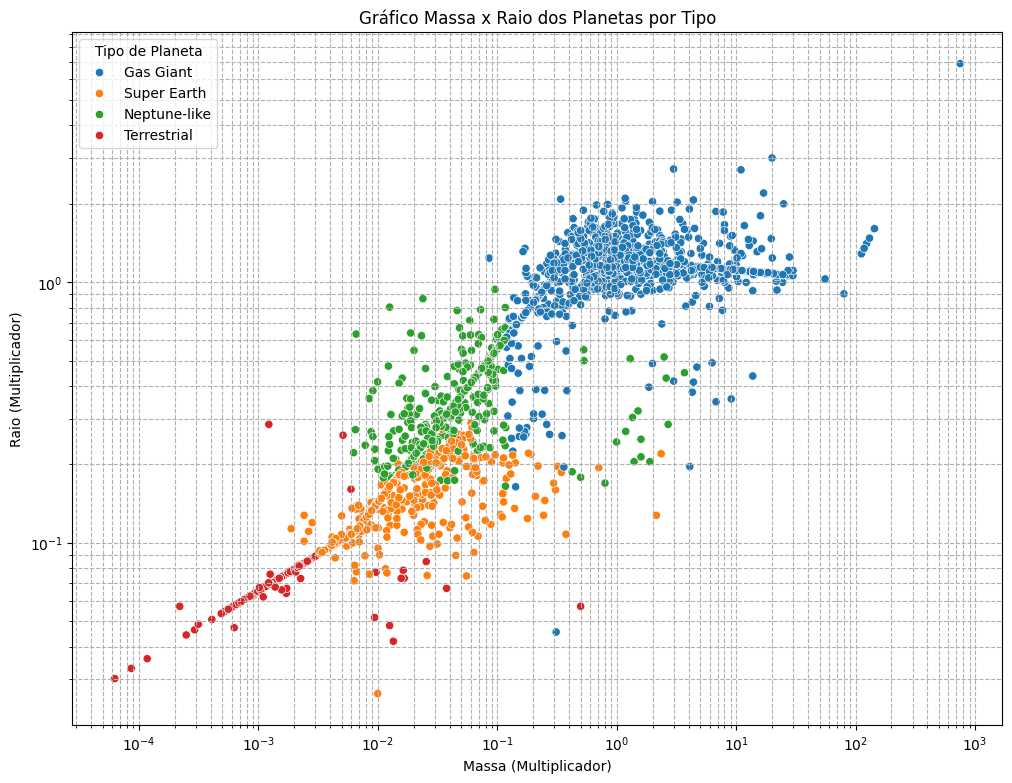

In [135]:
# Define o tamanho da figura para melhor visualização com a legenda
plt.figure(figsize=(12, 9))

# Cria o scatter plot, usando 'hue' para colorir os pontos por 'planet_type'
sns.scatterplot(data=df_reg, x='mass_multiplier', y='radius_multiplier', hue='planet_type')

# Adiciona títulos e rótulos
plt.title('Gráfico Massa x Raio dos Planetas por Tipo')
plt.xlabel('Massa (Multiplicador)')
plt.ylabel('Raio (Multiplicador)')

# Usa escala logarítmica para melhor visualização
plt.xscale('log')
plt.yscale('log')

# Adiciona uma grade e uma legenda
plt.grid(True, which="both", ls="--")
plt.legend(title='Tipo de Planeta')

# Mostra o gráfico
plt.show()


Analisando o Scatter-Plot de Raio x Massa, conseguimos perceber algumas coisas interessantes:

- Planetas Terrestres tendem a possuir uma densidade equivalente (Massa e Raio crescem de forma linear e igualmente)

- Existe um certo número de planetas observados que possuem densidade parecidas(As linhas crescentes observadas)

- A falta de planetas observáveis na região entre 'Tipo-Netuno' e 'Super-Terras'. Na literatura de astronomia, essa 'lacuna' é conhecida como: 'Radius Valley'

- Gigantes Gasosos tendem a ser menos densos que Super Terras


Agora, vamos analisar o período orbital dos planetas:

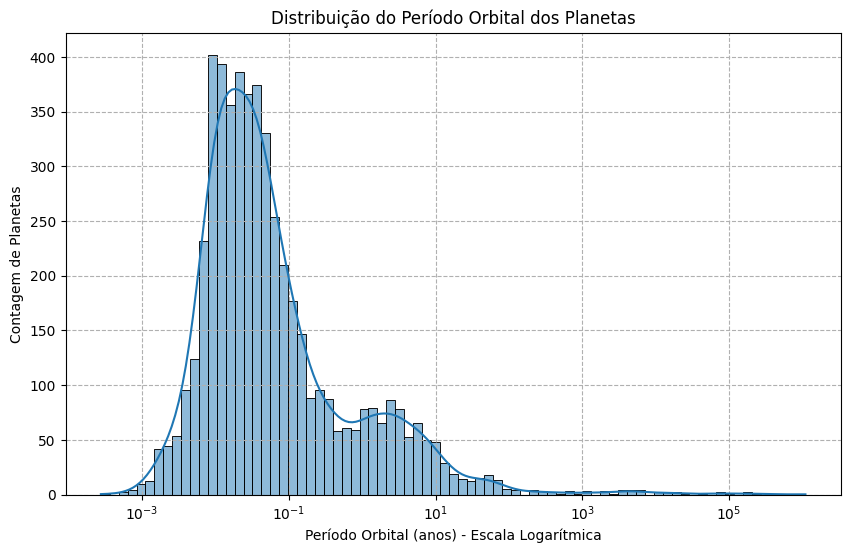

In [120]:
import matplotlib.pyplot as plt
import seaborn as sns

# Supondo que seu DataFrame 'df' já esteja carregado e tratado

# Cria a figura e define o tamanho
plt.figure(figsize=(10, 6))

# Cria o histograma para a coluna 'orbital_period'.
# Usamos log_scale=True para aplicar a escala logarítmica diretamente no eixo x.
# O parâmetro kde=True adiciona uma linha suave que estima a distribuição.
sns.histplot(data=df_reg, x='orbital_period', kde=True, log_scale=True)

# Define o título e os rótulos dos eixos
plt.title('Distribuição do Período Orbital dos Planetas')
plt.xlabel('Período Orbital (anos) - Escala Logarítmica')
plt.ylabel('Contagem de Planetas')

# Adiciona uma grade para facilitar a leitura
plt.grid(True, which="both", ls="--")

# Exibe o gráfico
plt.show()


Conforme é possível observar, existe uma observação maior de exoplanetas que possuem um período orbital menor. Essa maior concentração se deve às formas mais comuns e eficientes de identificar um exoplaneta, que são a Técnica de Trânsito e a Velocidade Radial, que consiste em identificar o planeta justamente pelo seu período de órbita. Planetas com um período elevado de órbita são dificilmente encontrados utilizando esse método

Agora, vamos fazer a matriz de correlação entre as variáveis para identificar os atributos mais relacionados no nosso dataset:


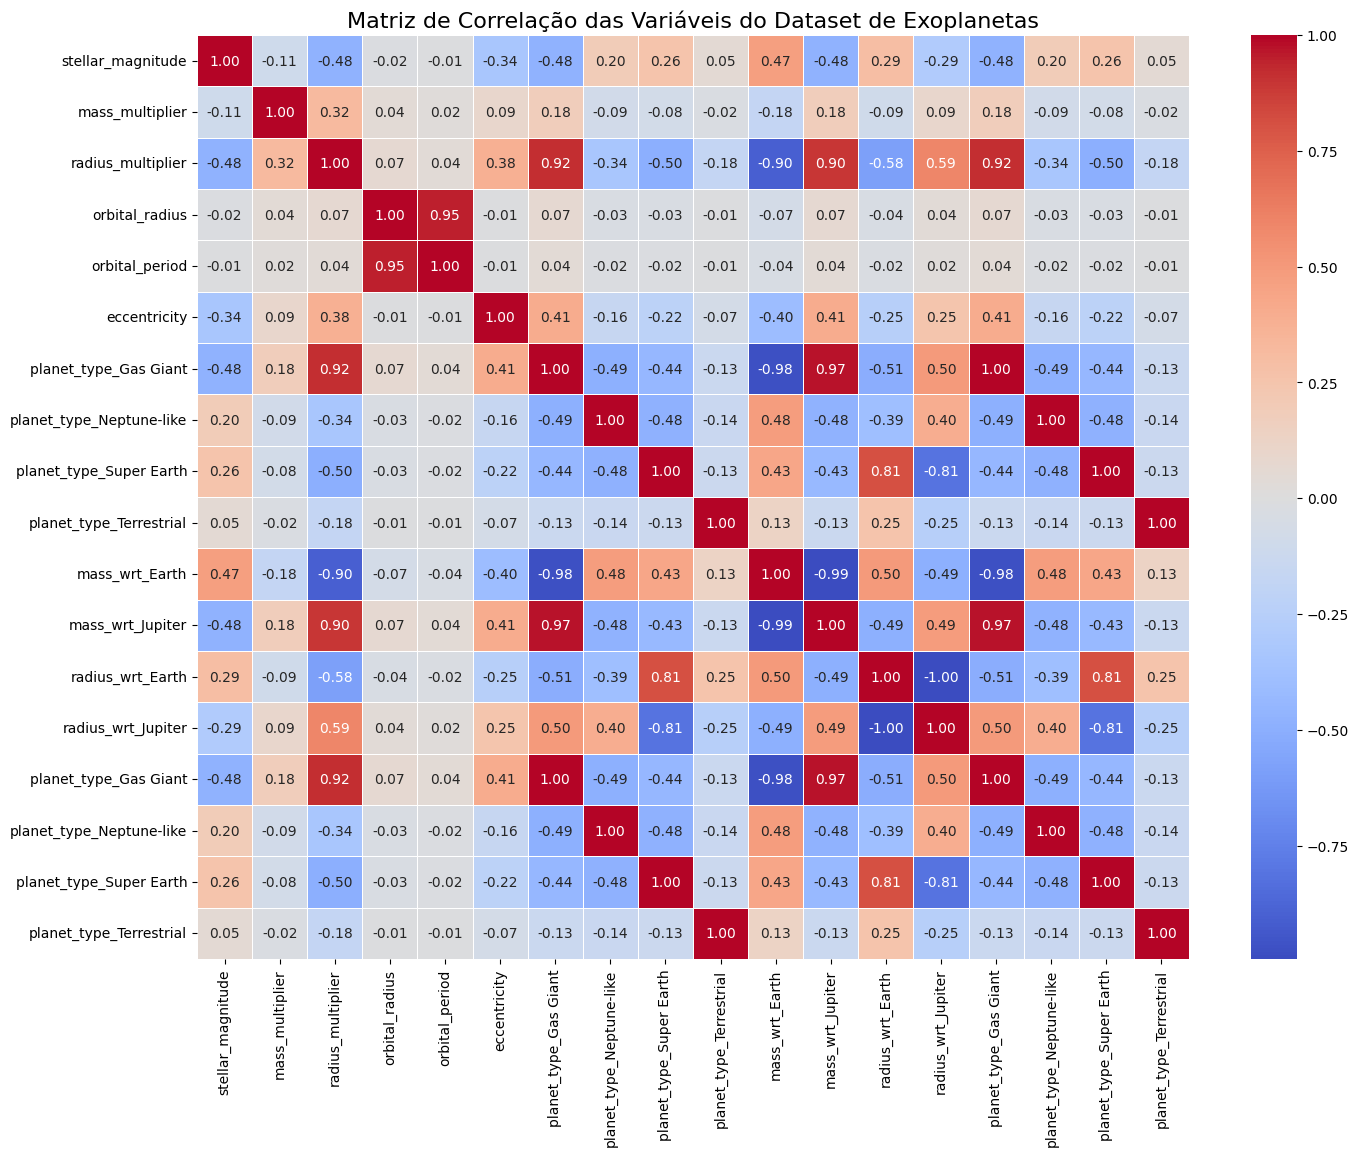

In [121]:
import matplotlib.pyplot as plt
import seaborn as sns

# Supondo que seu DataFrame 'df' já esteja carregado e tratado

df = pd.get_dummies(df)
corr_matrix = df.corr()


plt.figure(figsize=(16, 12))


sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)

plt.title('Matriz de Correlação das Variáveis do Dataset de Exoplanetas', fontsize=16)

plt.show()